# 🧠 ActivationLab
## The Complete Neural Network Activation Function Visualizer

### 👨‍💻 Author
**Raj Halwai**

---

## 📖 Overview

Activation functions are one of the most important components of neural networks. They determine whether a neuron should be activated by transforming its input into a meaningful output. Choosing the right activation function directly impacts learning speed, gradient flow, convergence, and overall model performance.

This notebook implements every major activation function **from scratch using only NumPy and Mathematics**, without relying on TensorFlow or PyTorch. Along with visualization, this project demonstrates their derivatives, gradient behavior, common challenges such as vanishing gradients and dead neurons, and practical real-world applications.

---

## 🎯 Objectives

This project covers:

- Implement major activation functions from scratch
- Implement their derivatives manually
- Visualize activation curves
- Compare activation functions side-by-side
- Understand vanishing gradients
- Demonstrate the dying ReLU problem
- Explore Softmax probability distributions
- Build an educational cheat sheet
- Learn where each activation function is used in modern Deep Learning

---

## 🛠 Technologies Used

- Python
- NumPy
- Matplotlib
- math

---

## 📌 Activation Functions Covered

- Sigmoid
- Tanh
- ReLU
- Leaky ReLU
- ELU
- Swish
- Softmax

---

**Let's begin by importing the required libraries and implementing each activation function from scratch.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Better plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 🧮 Mathematical Implementation

In this section, we implement every activation function manually using mathematical equations.

**No Deep Learning libraries are used.**

Each function is implemented exactly as defined in neural network theory.

In [ ]:
#Activation Function

def sigmoid(x):
  """
  Sigmoid Activation Function

  Formula : σ(x) = 1 / (1 + e^(-x))
  """
  return 1 / (1+np.exp(-x))

def tanh(x):
  """
  Hyperbolic Tangent

  Formula : tanh(x)
  """
  return np.tanh(x)

def relu(x):
  """
  ReLU activation

  Formula : max(0, x)
  """
  return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    """
    Leaky ReLU

    Formula:
        x      if x > 0
        αx     otherwise
    """
    return np.where(x > 0, x, alpha * x)


def elu(x, alpha=1.0):
    """
    Exponential Linear Unit (ELU)

    Formula:
        x                     if x > 0
        α(e^x - 1)            otherwise
    """
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))


def swish(x):
    """
    Swish Activation

    Formula: x * sigmoid(x)
    """
    return x * sigmoid(x)


def softmax(x):
    """
    Numerically Stable Softmax

    Formula: e^(x-max(x)) / Σe^(x-max(x))
    """

    shifted = x - np.max(x)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values)

# 📐 Derivatives of Activation Functions

Backpropagation relies on derivatives to update neural network weights.

In this section, we manually implement the derivative of every activation function without using automatic differentiation.

In [ ]:
# Derivatives

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2


def relu_derivative(x):
    return np.where(x > 0, 1.0, 0.0)


def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1.0, alpha)


def elu_derivative(x, alpha=1.0):
    return np.where(x > 0, 1.0, alpha * np.exp(x))


def swish_derivative(x):
    s = sigmoid(x)
    return s + x * s * (1 - s)

In [ ]:
# Function Verification

x = np.linspace(-5, 5, 11)

print("Input Values:\n")
print(x)

print("\nSigmoid:\n", np.round(sigmoid(x), 3))

print("\nTanh:\n", np.round(tanh(x), 3))

print("\nReLU:\n", relu(x))

print("\nLeaky ReLU:\n", np.round(leaky_relu(x), 3))

print("\nELU:\n", np.round(elu(x), 3))

print("\nSwish:\n", np.round(swish(x), 3))

sample = np.array([2.0, 1.0, 0.5])

print("\nSoftmax:\n", np.round(softmax(sample), 3))

Input Values:

[-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.]

Sigmoid:
 [0.007 0.018 0.047 0.119 0.269 0.5   0.731 0.881 0.953 0.982 0.993]

Tanh:
 [-1.    -0.999 -0.995 -0.964 -0.762  0.     0.762  0.964  0.995  0.999
  1.   ]

ReLU:
 [0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 5.]

Leaky ReLU:
 [-0.05 -0.04 -0.03 -0.02 -0.01  0.    1.    2.    3.    4.    5.  ]

ELU:
 [-0.993 -0.982 -0.95  -0.865 -0.632  0.     1.     2.     3.     4.
  5.   ]

Swish:
 [-0.033 -0.072 -0.142 -0.238 -0.269  0.     0.731  1.762  2.858  3.928
  4.967]

Softmax:
 [0.629 0.231 0.14 ]


# 📈 Section 1 — Individual Activation Function Visualizations

Each activation function is plotted together with its derivative.

The derivative determines how gradients flow during backpropagation, making it one of the most important characteristics of an activation function.

Every plot includes:

- Activation curve
- Derivative curve
- Mathematical formula
- Output range
- Common use case

In [ ]:
# Common Input Range

x = np.linspace(-5, 5 ,500)

In [ ]:
# Professional Plot Function

def plot_activation(
    x,
    activation,
    derivative,
    title,
    formula,
    output_range,
    use_case,
    color
):

    plt.figure(figsize=(9,5))

    # Activation
    plt.plot(
        x,
        activation(x),
        linewidth=3,
        color=color,
        label="Activation"
    )

    # Derivative
    plt.plot(
        x,
        derivative(x),
        linewidth=3,
        linestyle="--",
        color="black",
        label="Derivative"
    )

    plt.axhline(0,color='gray',linewidth=1)
    plt.axvline(0,color='gray',linewidth=1)

    plt.title(title, fontsize=16, weight='bold')

    plt.xlabel("Input (x)")
    plt.ylabel("Output")

    plt.grid(alpha=0.3)

    plt.legend()

    info = (
        f"Formula:\n{formula}\n\n"
        f"Output Range:\n{output_range}\n\n"
        f"Typical Use:\n{use_case}"
    )

    plt.text(
        2.2,
        np.min(activation(x)),
        info,
        fontsize=10,
        bbox=dict(
            facecolor='white',
            edgecolor='gray',
            alpha=0.9
        )
    )

    plt.tight_layout()

    plt.show()

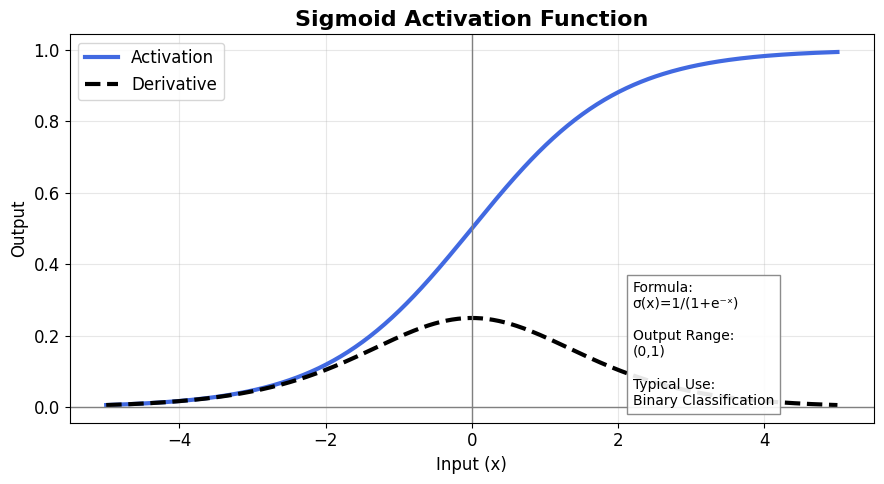

In [ ]:
plot_activation(
    x=x,
    activation=sigmoid,
    derivative=sigmoid_derivative,
    title="Sigmoid Activation Function",
    formula="σ(x)=1/(1+e⁻ˣ)",
    output_range="(0,1)",
    use_case="Binary Classification",
    color="royalblue"
)

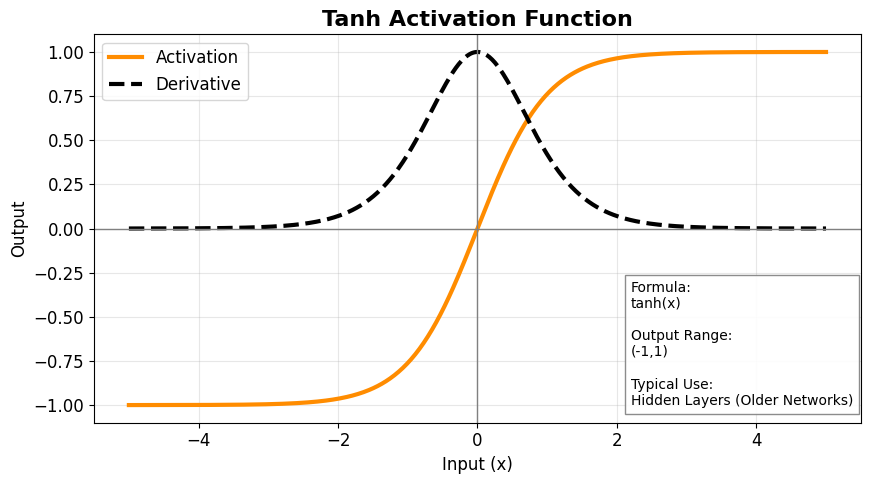

In [ ]:
plot_activation(
    x=x,
    activation=tanh,
    derivative=tanh_derivative,
    title="Tanh Activation Function",
    formula="tanh(x)",
    output_range="(-1,1)",
    use_case="Hidden Layers (Older Networks)",
    color="darkorange"
)

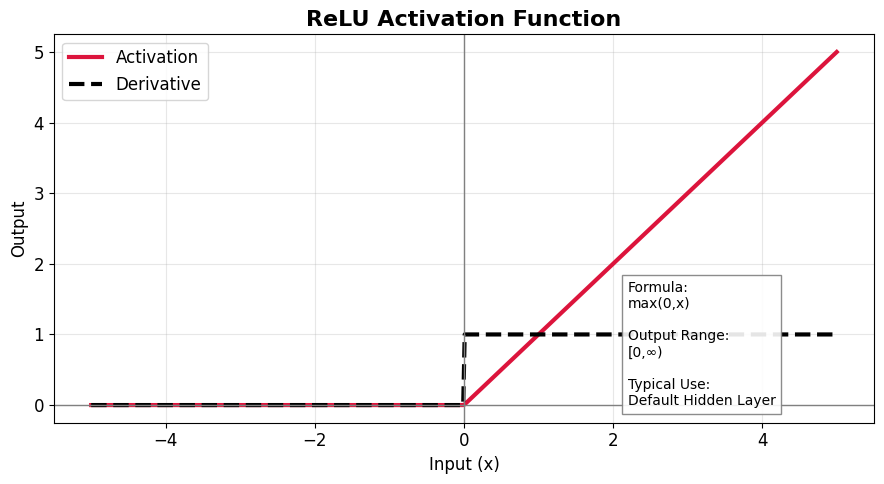

In [ ]:
plot_activation(
    x=x,
    activation=relu,
    derivative=relu_derivative,
    title="ReLU Activation Function",
    formula="max(0,x)",
    output_range="[0,∞)",
    use_case="Default Hidden Layer",
    color="crimson"
)

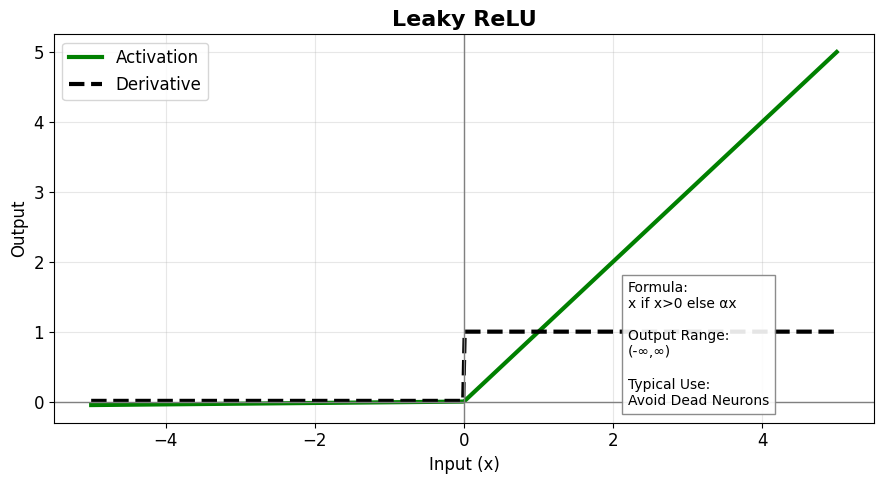

In [ ]:
plot_activation(
    x=x,
    activation=leaky_relu,
    derivative=leaky_relu_derivative,
    title="Leaky ReLU",
    formula="x if x>0 else αx",
    output_range="(-∞,∞)",
    use_case="Avoid Dead Neurons",
    color="green"
)

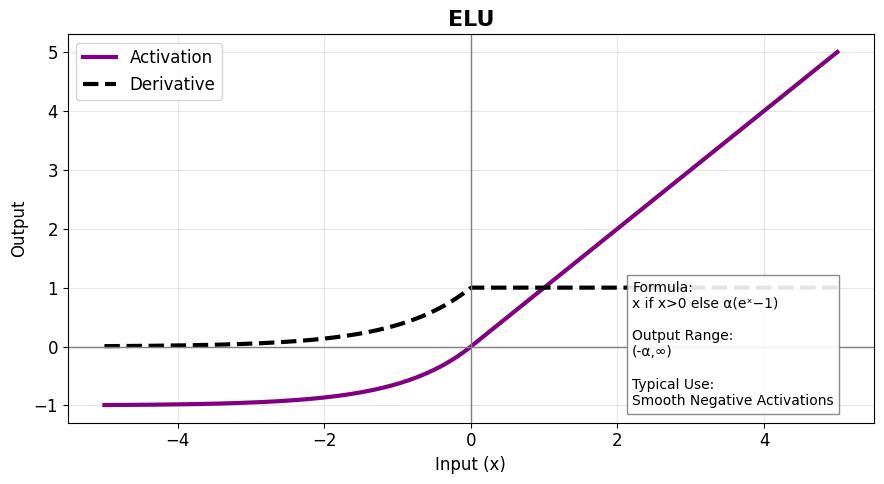

In [ ]:
plot_activation(
    x=x,
    activation=elu,
    derivative=elu_derivative,
    title="ELU",
    formula="x if x>0 else α(eˣ−1)",
    output_range="(-α,∞)",
    use_case="Smooth Negative Activations",
    color="purple"
)

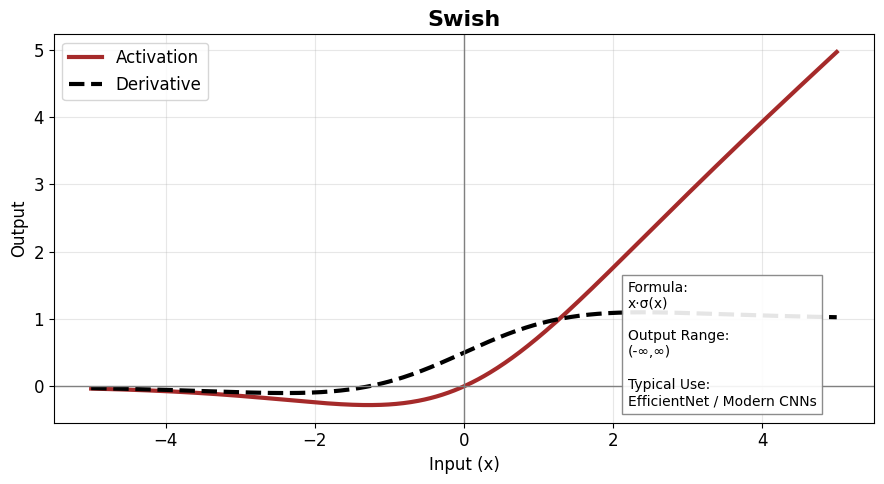

In [ ]:
plot_activation(
    x=x,
    activation=swish,
    derivative=swish_derivative,
    title="Swish",
    formula="x·σ(x)",
    output_range="(-∞,∞)",
    use_case="EfficientNet / Modern CNNs",
    color="brown"
)

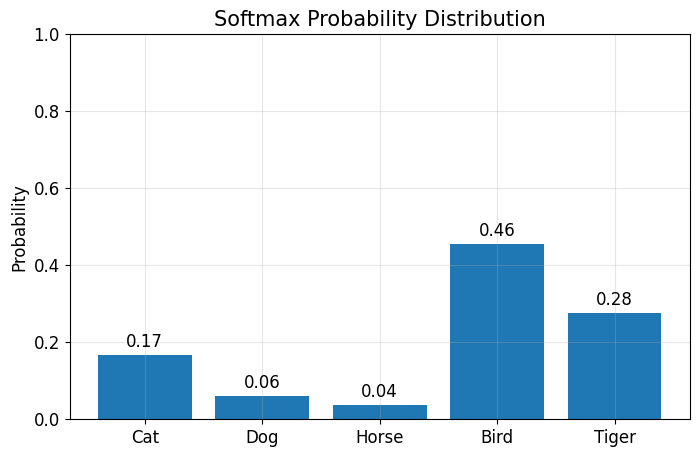

In [ ]:
#Softmax is different because it operates on a vector, not individual scalar inputs.

# Sample logits
sample = np.array([2.0, 1.0, 0.5, 3.0, 2.5])

labels = ["Cat","Dog","Horse","Bird","Tiger"]

prob = softmax(sample)

plt.figure(figsize=(8,5))

bars = plt.bar(labels, prob)

plt.title("Softmax Probability Distribution", fontsize=15)

plt.ylabel("Probability")

plt.ylim(0,1)

plt.grid(axis='y', alpha=0.3)

for bar,p in zip(bars,prob):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        p+0.02,
        f"{p:.2f}",
        ha='center'
    )

plt.show()

# 📊 Section 2 — Side-by-Side Activation Function Comparison

Looking at one activation function at a time makes it difficult to understand their differences.

This section compares every major activation function on the same input range (`-5` to `5`) using identical axis limits. This allows us to directly compare their shapes, output ranges, saturation behavior, and non-linearity.

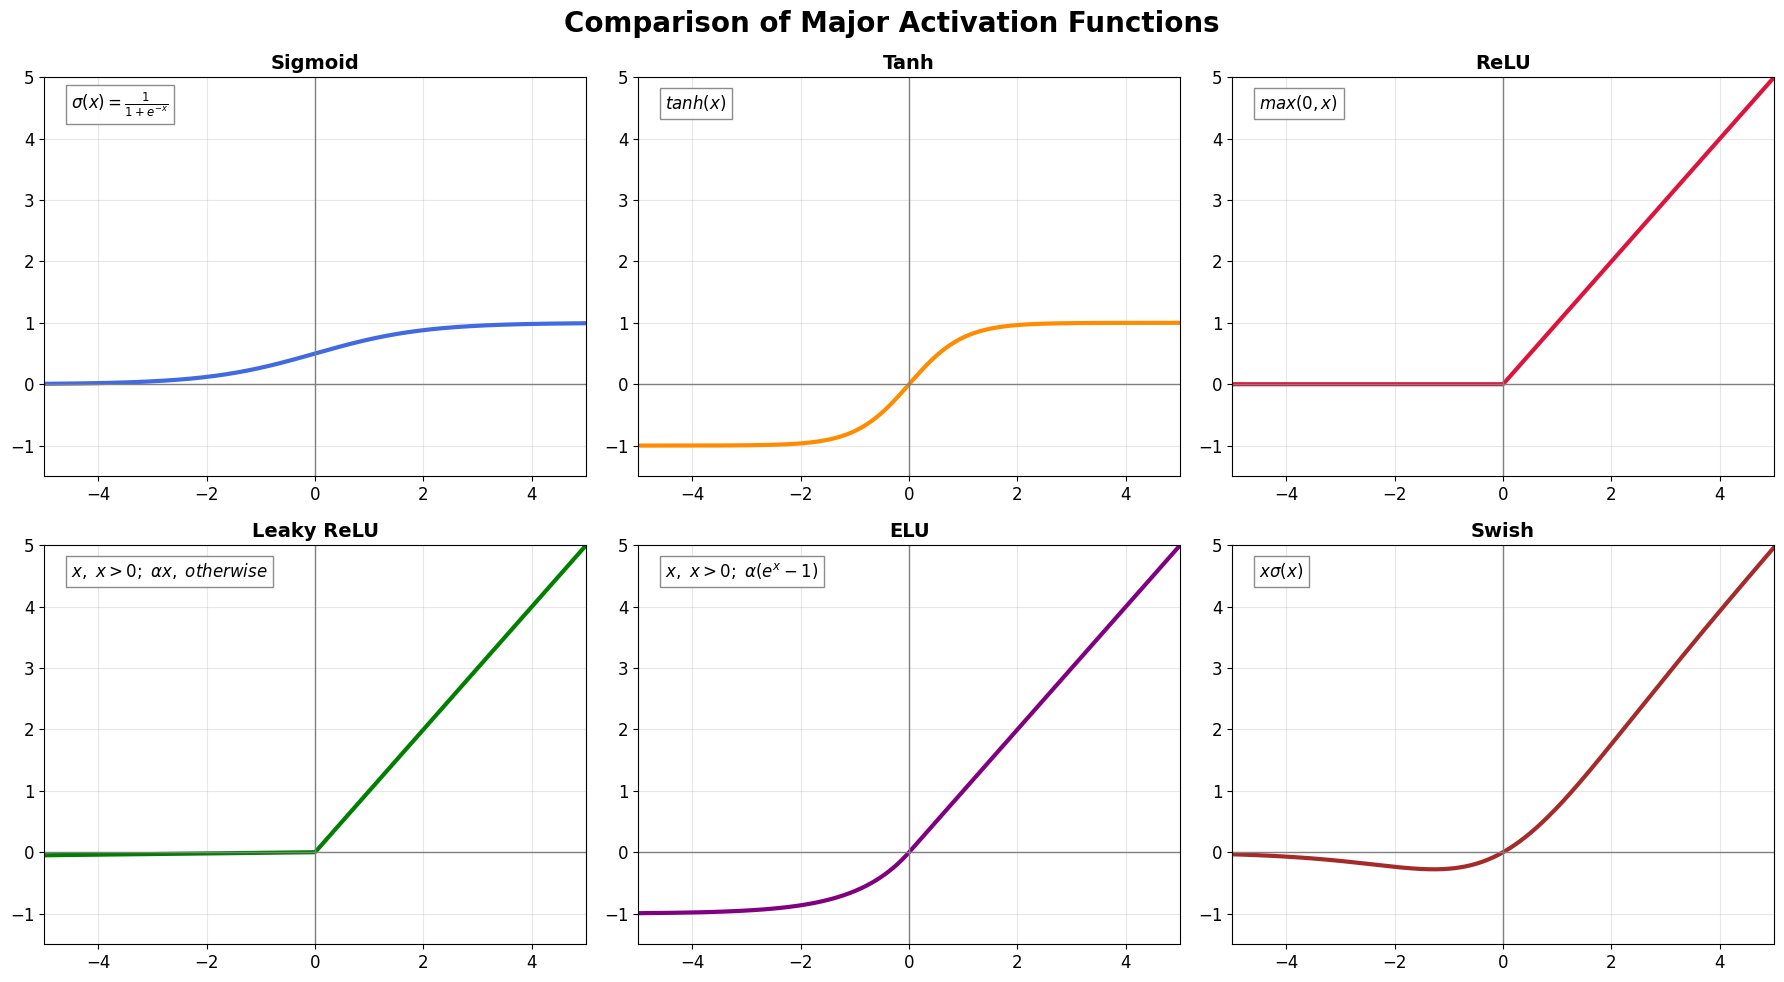

In [ ]:
# Side-by-Side Activation Function Comparison

activation_info = [
    {
        "name": "Sigmoid",
        "function": sigmoid,
        "formula": r"$\sigma(x)=\frac{1}{1+e^{-x}}$",
        "color": "royalblue"
    },
    {
        "name": "Tanh",
        "function": tanh,
        "formula": r"$tanh(x)$",
        "color": "darkorange"
    },
    {
        "name": "ReLU",
        "function": relu,
        "formula": r"$max(0,x)$",
        "color": "crimson"
    },
    {
        "name": "Leaky ReLU",
        "function": leaky_relu,
        "formula": r"$x,\ x>0;\ \alpha x,\ otherwise$",
        "color": "green"
    },
    {
        "name": "ELU",
        "function": elu,
        "formula": r"$x,\ x>0;\ \alpha(e^x-1)$",
        "color": "purple"
    },
    {
        "name": "Swish",
        "function": swish,
        "formula": r"$x\sigma(x)$",
        "color": "brown"
    }
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.ravel()

for ax, act in zip(axes, activation_info):

    y = act["function"](x)

    ax.plot(
        x,
        y,
        color=act["color"],
        linewidth=3
    )

    ax.axhline(0, color="gray", linewidth=1)
    ax.axvline(0, color="gray", linewidth=1)

    ax.set_title(act["name"], fontsize=14, weight="bold")

    ax.set_xlim(-5, 5)
    ax.set_ylim(-1.5, 5)

    ax.grid(alpha=0.3)

    ax.text(
        0.05,
        0.92,
        act["formula"],
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(
            facecolor="white",
            alpha=0.9,
            edgecolor="gray"
        )
    )

fig.suptitle(
    "Comparison of Major Activation Functions",
    fontsize=20,
    weight="bold"
)

plt.tight_layout()

plt.show()

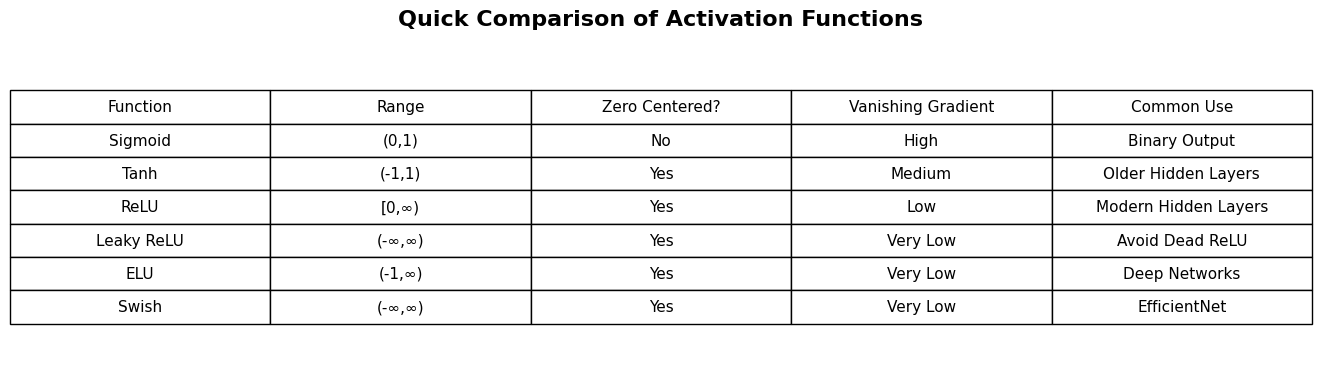

In [ ]:
comparison_data = [
    ["Sigmoid", "(0,1)", "No", "High", "Binary Output"],
    ["Tanh", "(-1,1)", "Yes", "Medium", "Older Hidden Layers"],
    ["ReLU", "[0,∞)", "Yes", "Low", "Modern Hidden Layers"],
    ["Leaky ReLU", "(-∞,∞)", "Yes", "Very Low", "Avoid Dead ReLU"],
    ["ELU", "(-1,∞)", "Yes", "Very Low", "Deep Networks"],
    ["Swish", "(-∞,∞)", "Yes", "Very Low", "EfficientNet"],
]

columns = [
    "Function",
    "Range",
    "Zero Centered?",
    "Vanishing Gradient",
    "Common Use"
]

fig, ax = plt.subplots(figsize=(14,4))

ax.axis('off')

table = ax.table(
    cellText=comparison_data,
    colLabels=columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,2)

plt.title(
    "Quick Comparison of Activation Functions",
    fontsize=16,
    weight='bold',
    pad=20
)

plt.show()

# 📉 Section 3 — Derivative Comparison

Activation functions determine the forward pass of a neural network, but their derivatives determine how gradients flow during backpropagation.

A derivative close to zero causes gradients to shrink, making learning slow or even impossible in deep networks.

This visualization compares the derivatives of all major activation functions using the same input range and axis scale.

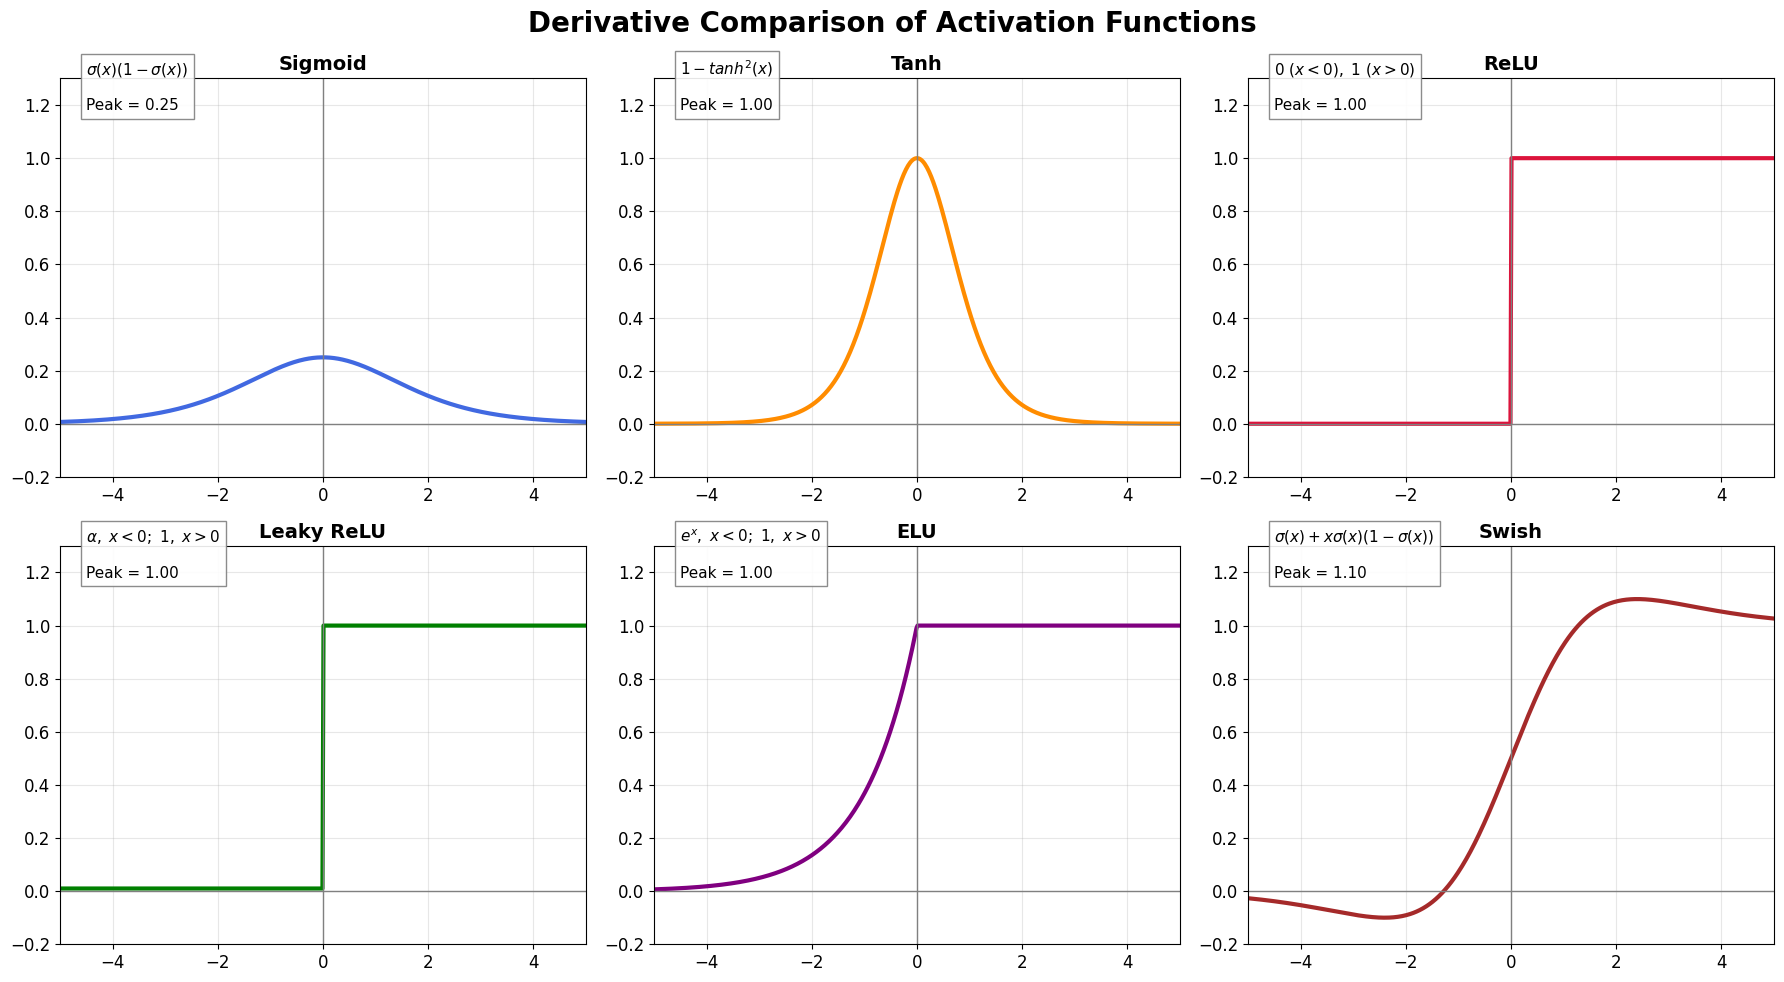

In [ ]:
# Derivative Comparison Dashboard
derivative_info = [
    {
        "name": "Sigmoid",
        "function": sigmoid_derivative,
        "formula": r"$\sigma(x)(1-\sigma(x))$",
        "color": "royalblue"
    },
    {
        "name": "Tanh",
        "function": tanh_derivative,
        "formula": r"$1-tanh^2(x)$",
        "color": "darkorange"
    },
    {
        "name": "ReLU",
        "function": relu_derivative,
        "formula": r"$0\ (x<0),\ 1\ (x>0)$",
        "color": "crimson"
    },
    {
        "name": "Leaky ReLU",
        "function": leaky_relu_derivative,
        "formula": r"$\alpha,\ x<0;\ 1,\ x>0$",
        "color": "green"
    },
    {
        "name": "ELU",
        "function": elu_derivative,
        "formula": r"$e^x,\ x<0;\ 1,\ x>0$",
        "color": "purple"
    },
    {
        "name": "Swish",
        "function": swish_derivative,
        "formula": r"$\sigma(x)+x\sigma(x)(1-\sigma(x))$",
        "color": "brown"
    }
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, act in zip(axes, derivative_info):

    y = act["function"](x)

    ax.plot(
        x,
        y,
        color=act["color"],
        linewidth=3
    )

    ax.axhline(0, color="gray", linewidth=1)
    ax.axvline(0, color="gray", linewidth=1)

    ax.set_xlim(-5,5)
    ax.set_ylim(-0.2,1.3)

    ax.grid(alpha=0.3)

    ax.set_title(
        act["name"],
        fontsize=14,
        weight="bold"
    )

    peak = np.max(y)

    ax.text(
        0.05,
        0.92,
        f"{act['formula']}\n\nPeak = {peak:.2f}",
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(
            facecolor="white",
            alpha=0.9,
            edgecolor="gray"
        )
    )

fig.suptitle(
    "Derivative Comparison of Activation Functions",
    fontsize=20,
    weight="bold"
)

plt.tight_layout()

plt.show()

## 🔍 Key Observations

### 🔵 Sigmoid
- Maximum derivative is only **0.25**
- Gradients rapidly approach zero for large positive and negative inputs
- Major cause of the **vanishing gradient problem**

---

### 🟠 Tanh
- Zero-centered output
- Larger gradients than Sigmoid near the origin
- Still suffers from vanishing gradients for extreme inputs

---

### 🔴 ReLU
- Gradient is **1** for all positive inputs
- No vanishing gradient on the positive side
- Gradient becomes **0** for negative inputs, leading to the **dying ReLU problem**

---

### 🟢 Leaky ReLU
- Maintains a small gradient on the negative side
- Prevents neurons from permanently dying

---

### 🟣 ELU
- Smooth transition around zero
- Better gradient flow for negative inputs than ReLU

---

### 🟤 Swish
- Smooth and non-monotonic
- Maintains useful gradients over a wider range
- One reason it performs well in very deep neural networks

# 🌊 Section 4 — Vanishing Gradient Simulation

Deep neural networks update their weights using gradients propagated backward through every layer.

If the derivative of an activation function is consistently small, multiplying these values across many layers causes the gradient to rapidly approach zero.

This experiment simulates a **5-layer neural network** and compares how gradients behave for:

- Sigmoid
- Tanh
- ReLU

The goal is to visually demonstrate why ReLU became the standard activation function for deep learning.

In [ ]:
# Vanishing Gradient Simulation
x = np.linspace(-5, 5, 500)

layers = 5

sigmoid_gradients = []
tanh_gradients = []
relu_gradients = []

sig_grad = np.ones_like(x)
tanh_grad = np.ones_like(x)
relu_grad = np.ones_like(x)

for layer in range(layers):

    sig_grad *= sigmoid_derivative(x)
    tanh_grad *= tanh_derivative(x)
    relu_grad *= relu_derivative(x)

    sigmoid_gradients.append(sig_grad.copy())
    tanh_gradients.append(tanh_grad.copy())
    relu_gradients.append(relu_grad.copy())

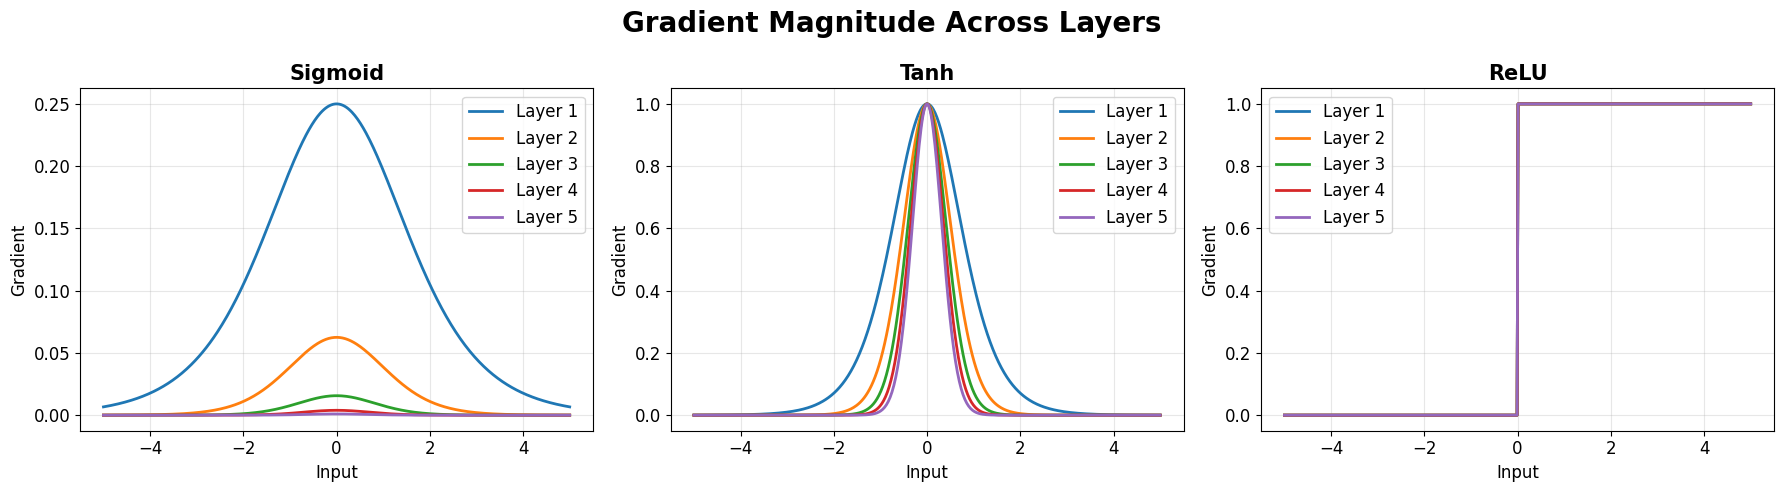

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

titles = ["Sigmoid", "Tanh", "ReLU"]

gradient_sets = [
    sigmoid_gradients,
    tanh_gradients,
    relu_gradients
]

colors = ["royalblue","darkorange","crimson"]

for ax, grads, title, color in zip(
    axes,
    gradient_sets,
    titles,
    colors
):

    for i, g in enumerate(grads):
        ax.plot(
            x,
            g,
            linewidth=2,
            label=f"Layer {i+1}"
        )

    ax.set_title(
        title,
        fontsize=15,
        weight='bold'
    )

    ax.set_xlabel("Input")

    ax.set_ylabel("Gradient")

    ax.grid(alpha=0.3)

    ax.legend()

plt.suptitle(
    "Gradient Magnitude Across Layers",
    fontsize=20,
    weight="bold"
)

plt.tight_layout()

plt.show()

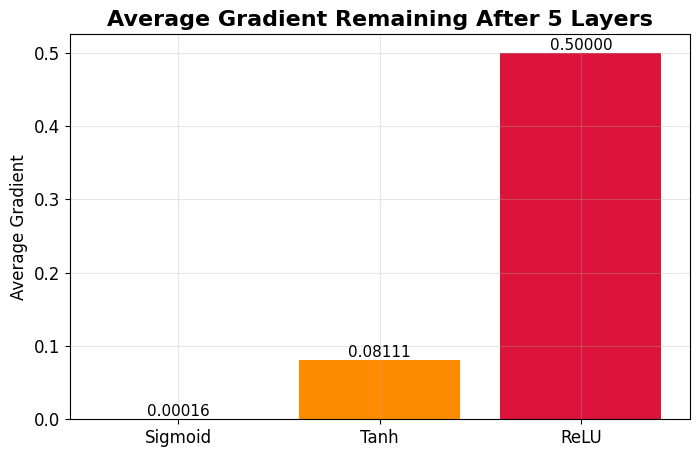

In [ ]:
final_sigmoid = np.mean(sigmoid_gradients[-1])
final_tanh = np.mean(tanh_gradients[-1])
final_relu = np.mean(relu_gradients[-1])

labels = ["Sigmoid","Tanh","ReLU"]

values = [
    final_sigmoid,
    final_tanh,
    final_relu
]

colors = [
    "royalblue",
    "darkorange",
    "crimson"
]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values, color=colors)

plt.title(
    "Average Gradient Remaining After 5 Layers",
    fontsize=16,
    weight="bold"
)

plt.ylabel("Average Gradient")

for bar, value in zip(bars, values):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        value,
        f"{value:.5f}",
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.grid(axis='y', alpha=0.3)

plt.show()

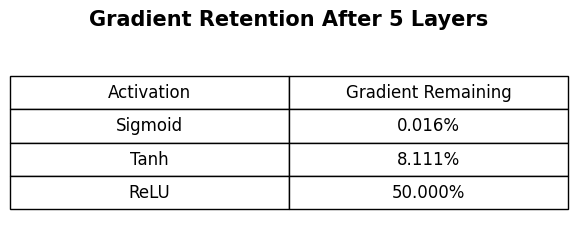

In [ ]:
gradient_table = [
    [
        "Sigmoid",
        f"{final_sigmoid*100:.3f}%"
    ],
    [
        "Tanh",
        f"{final_tanh*100:.3f}%"
    ],
    [
        "ReLU",
        f"{final_relu*100:.3f}%"
    ]
]

fig, ax = plt.subplots(figsize=(6,2.5))

ax.axis('off')

table = ax.table(
    cellText=gradient_table,
    colLabels=["Activation","Gradient Remaining"],
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,2)

plt.title(
    "Gradient Retention After 5 Layers",
    fontsize=15,
    weight="bold",
    pad=15
)

plt.show()

## 📌 Interpretation

### 🔵 Sigmoid

The gradient rapidly approaches zero after only a few layers because its derivative is always less than or equal to **0.25**. This makes training deep neural networks extremely difficult.

---

### 🟠 Tanh

Tanh performs better than Sigmoid because it is zero-centered and has larger derivatives near zero. However, it still suffers from vanishing gradients for large positive and negative inputs.

---

### 🔴 ReLU

For positive inputs, the derivative remains exactly **1**, allowing gradients to pass through multiple layers without shrinking.

This simple property is one of the biggest reasons why ReLU became the default activation function in modern deep learning.

# ☠️ Section 5 — Dead ReLU Demonstration

One limitation of the ReLU activation function is the **Dying ReLU Problem**.

If a neuron's input becomes negative, ReLU outputs zero. During backpropagation, its derivative is also zero, meaning the neuron receives no gradient updates and may never recover.

Leaky ReLU and ELU address this issue by allowing negative inputs to produce small non-zero outputs.

This experiment compares the output distributions of ReLU, Leaky ReLU, and ELU using the same set of negative inputs.

In [ ]:
# Generate Negative Inputs
np.random.seed(42)

negative_inputs = np.random.normal(
    loc=-5,
    scale=1,
    size=1000
)

relu_output = relu(negative_inputs)

leaky_output = leaky_relu(negative_inputs)

elu_output = elu(negative_inputs)

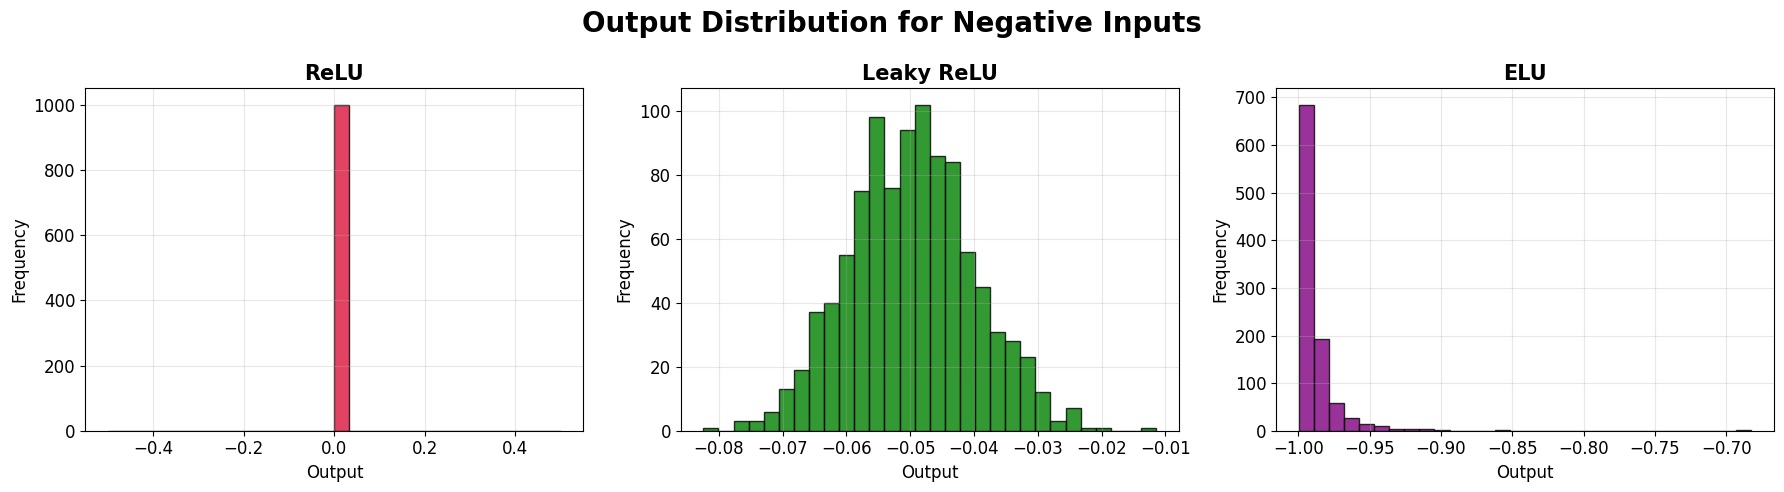

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

plots = [
    ("ReLU", relu_output, "crimson"),
    ("Leaky ReLU", leaky_output, "green"),
    ("ELU", elu_output, "purple")
]

for ax, (title, data, color) in zip(axes, plots):

    ax.hist(
        data,
        bins=30,
        color=color,
        edgecolor="black",
        alpha=0.8
    )

    ax.set_title(
        title,
        fontsize=15,
        weight="bold"
    )

    ax.set_xlabel("Output")

    ax.set_ylabel("Frequency")

    ax.grid(alpha=0.3)

plt.suptitle(
    "Output Distribution for Negative Inputs",
    fontsize=20,
    weight="bold"
)

plt.tight_layout()

plt.show()

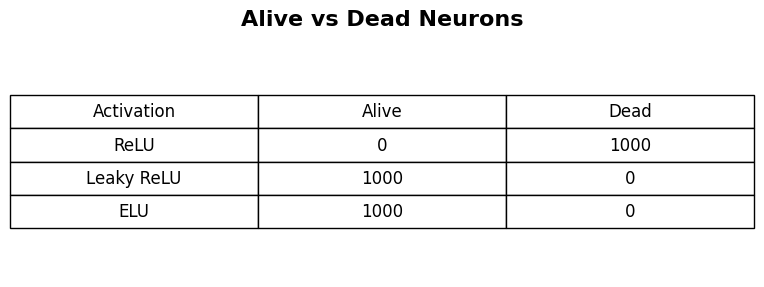

In [ ]:
relu_dead = np.sum(relu_output == 0)
relu_alive = len(relu_output) - relu_dead

leaky_dead = np.sum(leaky_output == 0)
leaky_alive = len(leaky_output) - leaky_dead

elu_dead = np.sum(elu_output == 0)
elu_alive = len(elu_output) - elu_dead

summary = [
    ["ReLU", relu_alive, relu_dead],
    ["Leaky ReLU", leaky_alive, leaky_dead],
    ["ELU", elu_alive, elu_dead]
]

fig, ax = plt.subplots(figsize=(8,3))

ax.axis('off')

table = ax.table(
    cellText=summary,
    colLabels=["Activation","Alive","Dead"],
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,2)

plt.title(
    "Alive vs Dead Neurons",
    fontsize=16,
    weight="bold",
    pad=15
)

plt.show()

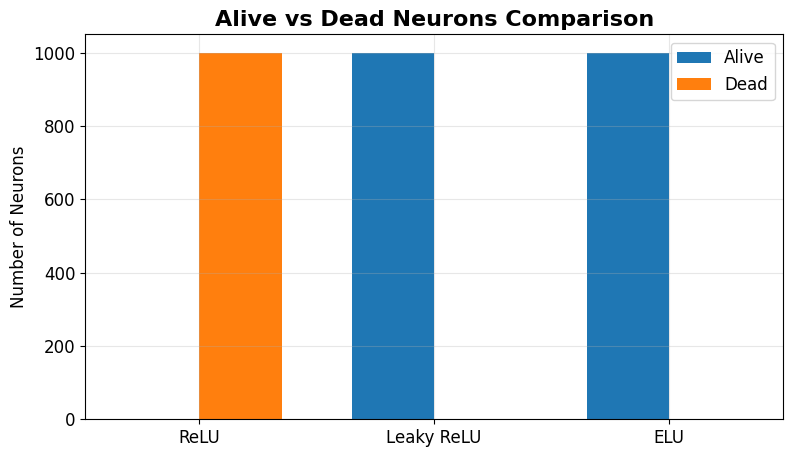

In [ ]:
alive = [relu_alive, leaky_alive, elu_alive]
dead = [relu_dead, leaky_dead, elu_dead]

labels = ["ReLU", "Leaky ReLU", "ELU"]

x_pos = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    x_pos - width/2,
    alive,
    width,
    label="Alive"
)

plt.bar(
    x_pos + width/2,
    dead,
    width,
    label="Dead"
)

plt.xticks(x_pos, labels)

plt.ylabel("Number of Neurons")

plt.title(
    "Alive vs Dead Neurons Comparison",
    fontsize=16,
    weight="bold"
)

plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.show()

## 📌 Interpretation

### 🔴 ReLU

All neurons receiving sufficiently negative inputs produce an output of zero. Their gradients also become zero, meaning they stop learning. This is known as the **Dying ReLU Problem**.

---

### 🟢 Leaky ReLU

Leaky ReLU introduces a small slope for negative inputs, allowing gradients to continue flowing. As a result, neurons remain active and can recover during training.

---

### 🟣 ELU

ELU smoothly transitions into negative values rather than abruptly becoming zero. This helps maintain gradient flow while keeping the mean activation closer to zero, which can improve optimization in deep neural networks.

---

### ✅ Key Takeaway

ReLU is simple and computationally efficient, but Leaky ReLU and ELU provide more robust gradient flow for negative inputs, reducing the risk of permanently inactive neurons.

# Section 6 — Activation Heatmap

Visualizing activation functions individually helps us understand their mathematical behavior, but comparing all of them together on the same input provides deeper intuition.

This heatmap shows how identical input values are transformed by different activation functions.

Each row represents one activation function, while each column represents the same input value.

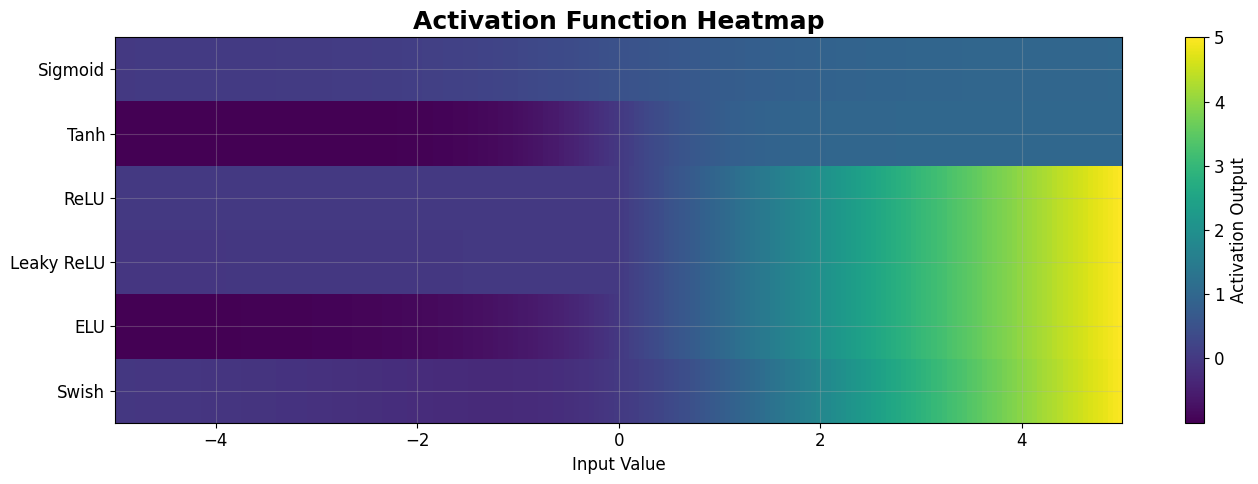

In [ ]:
# Activation Heatmap
heatmap_x = np.linspace(-5, 5, 200)

heatmap_data = np.array([
    sigmoid(heatmap_x),
    tanh(heatmap_x),
    relu(heatmap_x),
    leaky_relu(heatmap_x),
    elu(heatmap_x),
    swish(heatmap_x)
])

labels = [
    "Sigmoid",
    "Tanh",
    "ReLU",
    "Leaky ReLU",
    "ELU",
    "Swish"
]

plt.figure(figsize=(14,5))

im = plt.imshow(
    heatmap_data,
    aspect="auto",
    cmap="viridis",
    extent=[-5,5,6,0]
)

plt.yticks(
    np.arange(0.5,6.5),
    labels
)

plt.xlabel("Input Value")

plt.title(
    "Activation Function Heatmap",
    fontsize=18,
    weight="bold"
)

plt.colorbar(im,label="Activation Output")

plt.tight_layout()

plt.show()

## 📌 Interpretation

The heatmap highlights how each activation function transforms identical inputs:

- **Sigmoid** compresses all values into the range **(0,1)**.
- **Tanh** produces outputs centered around zero.
- **ReLU** removes all negative values.
- **Leaky ReLU** preserves a small response for negative inputs.
- **ELU** smoothly approaches a negative saturation value.
- **Swish** produces smooth nonlinear outputs while retaining small negative values.

This side-by-side visualization makes the behavioral differences between activation functions immediately apparent.

# ⚡ Section 7 — Numerical Stability of Softmax

The Softmax function involves exponentials, which can overflow for very large input values.

A common trick used in modern deep learning libraries is to subtract the maximum value before applying the exponential.

Although this changes the intermediate values, it **does not change the final probabilities**, making the computation numerically stable.

In [ ]:
# Numerical Stability Demo
large_logits = np.array([1000, 1001, 1002])

print("Input Logits:")
print(large_logits)

print("\nStable Softmax Probabilities:")
print(softmax(large_logits))

print("\nSum of Probabilities:")
print(np.sum(softmax(large_logits)))

Input Logits:
[1000 1001 1002]

Stable Softmax Probabilities:
[0.09003057 0.24472847 0.66524096]

Sum of Probabilities:
0.9999999999999999


# 📚 Section 8 — Activation Function Cheat Sheet

This cheat sheet summarizes the most important characteristics of each activation function.

It serves as a quick reference for selecting the appropriate activation function based on the task, output range, differentiability, and common limitations.

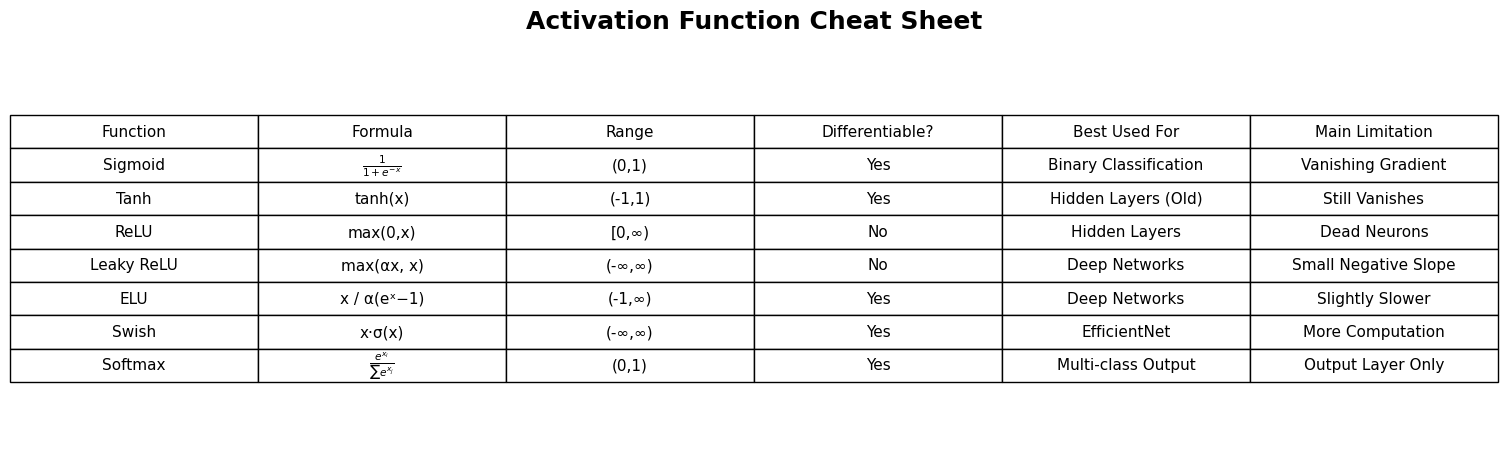

In [ ]:
# Activation Function Cheat Sheet
cheat_sheet = [
    [
        "Sigmoid",
        r"$\frac{1}{1+e^{-x}}$",
        "(0,1)",
        "Yes",
        "Binary Classification",
        "Vanishing Gradient"
    ],
    [
        "Tanh",
        "tanh(x)",
        "(-1,1)",
        "Yes",
        "Hidden Layers (Old)",
        "Still Vanishes"
    ],
    [
        "ReLU",
        "max(0,x)",
        "[0,∞)",
        "No",
        "Hidden Layers",
        "Dead Neurons"
    ],
    [
        "Leaky ReLU",
        "max(αx, x)",
        "(-∞,∞)",
        "No",
        "Deep Networks",
        "Small Negative Slope"
    ],
    [
        "ELU",
        "x / α(eˣ−1)",
        "(-1,∞)",
        "Yes",
        "Deep Networks",
        "Slightly Slower"
    ],
    [
        "Swish",
        "x·σ(x)",
        "(-∞,∞)",
        "Yes",
        "EfficientNet",
        "More Computation"
    ],
    [
        "Softmax",
        r"$\frac{e^{x_i}}{\sum e^{x_j}}$",
        "(0,1)",
        "Yes",
        "Multi-class Output",
        "Output Layer Only"
    ]
]

columns = [
    "Function",
    "Formula",
    "Range",
    "Differentiable?",
    "Best Used For",
    "Main Limitation"
]

fig, ax = plt.subplots(figsize=(16,5))

ax.axis("off")

table = ax.table(
    cellText=cheat_sheet,
    colLabels=columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,2)

plt.title(
    "Activation Function Cheat Sheet",
    fontsize=18,
    weight="bold",
    pad=20
)

plt.show()

# 🌍 Section 9 — Real-World Usage

Activation functions are not chosen randomly. Modern deep learning architectures use specific activation functions based on empirical performance, optimization behavior, and computational efficiency.

The table below lists some popular neural network architectures and the activation functions commonly associated with them.

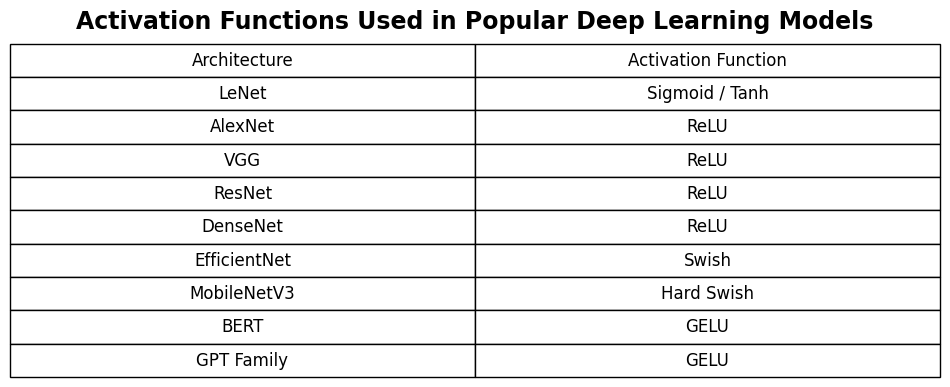

In [ ]:
# Real World Usage
real_world = [
    ["LeNet", "Sigmoid / Tanh"],
    ["AlexNet", "ReLU"],
    ["VGG", "ReLU"],
    ["ResNet", "ReLU"],
    ["DenseNet", "ReLU"],
    ["EfficientNet", "Swish"],
    ["MobileNetV3", "Hard Swish"],
    ["BERT", "GELU"],
    ["GPT Family", "GELU"]
]

fig, ax = plt.subplots(figsize=(10,4))

ax.axis("off")

table = ax.table(
    cellText=real_world,
    colLabels=["Architecture", "Activation Function"],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,2)

plt.title(
    "Activation Functions Used in Popular Deep Learning Models",
    fontsize=17,
    weight="bold",
    pad=20
)

plt.show()

# ✅ Key Takeaways

✔ Activation functions introduce non-linearity into neural networks.

✔ Sigmoid and Tanh are smooth but suffer from vanishing gradients.

✔ ReLU became the standard activation for deep networks because of its efficient gradient propagation.

✔ Leaky ReLU reduces the risk of permanently inactive neurons.

✔ ELU improves gradient flow with smooth negative activations.

✔ Swish is a modern activation function that often outperforms ReLU in very deep architectures.

✔ Softmax converts raw model outputs (logits) into a valid probability distribution.

✔ Choosing the right activation function can significantly impact training speed, convergence, and model performance.

# 🎉 Project Summary

In this project, we implemented and visualized the most widely used activation functions in deep learning entirely from scratch using NumPy and Matplotlib.

### What We Built

- ✅ Manual implementation of seven activation functions
- ✅ Manual implementation of their derivatives
- ✅ Individual activation and derivative visualizations
- ✅ Side-by-side comparison dashboard
- ✅ Derivative comparison dashboard
- ✅ Vanishing gradient simulation
- ✅ Dead ReLU demonstration
- ✅ Activation heatmap
- ✅ Softmax numerical stability demonstration
- ✅ Activation function cheat sheet
- ✅ Real-world architecture mapping
- ✅ Interview preparation section

This notebook is designed as both a learning resource and a practical reference for students beginning their deep learning journey.